# Examen MLOps — Modèle de scoring : risque d'escalade de conflit géopolitique

**Dataset** : `geopolitical_conflict_risk_dataset.csv` — 1320 observations mensuelles (2020-01 à 2025-06) pour 20 pays, avec pour cible `conflict_escalation_6m` (1 = escalade de conflit dans les 6 mois, 0 = sinon). Classe positive ≈ 31 % (déséquilibre modéré).

On suit les étapes de l'énoncé dans l'ordre :
1. Environnement MLflow
2. Préparation des données
3. Score métier (coût FP vs FN)
4. Entraînement / comparaison de modèles
5. API de scoring (hors notebook)
6. Interface Streamlit (hors notebook)
7. Data drift (hors notebook)


## Étape 1 — Préparation de l'environnement MLflow

MLflow tourne ici en local avec un backend de suivi basé sur SQLite (`mlflow.db`) et les artefacts stockés dans le dossier `mlruns/`. C'est suffisant pour un exercice — en entreprise on pointerait `tracking_uri` vers un serveur MLflow distant (ou une base PostgreSQL) partagé par l'équipe.

On crée une expérience dédiée `conflict-escalation-scoring`, puis on log un run "smoke test" (paramètres, métriques, un artefact texte) pour vérifier que le tracking fonctionne avant de s'en servir sérieusement à l'Étape 4.


In [1]:
import mlflow

# Backend de suivi local (fichier SQLite) + dossier d'artefacts local.
# En cloud, remplacer par l'URI d'un serveur MLflow distant, ex:
#   mlflow.set_tracking_uri("https://mon-serveur-mlflow.exemple.com")
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("conflict-escalation-scoring")

print("Tracking URI :", mlflow.get_tracking_uri())
print("Expérience active :", mlflow.get_experiment_by_name("conflict-escalation-scoring"))


Tracking URI : sqlite:///mlflow.db
Expérience active : <Experiment: artifact_location='file:C:/Users/G.Baroki/Machine_learning/classification/ExamensML/mlruns/1', creation_time=1784219912371, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1784219912371, lifecycle_stage='active', name='conflict-escalation-scoring', tags={}, trace_location=None, workspace='default'>


In [2]:
# Test de journalisation : un run "smoke test" pour vérifier que params, métriques
# et artefacts remontent bien dans l'UI MLflow (lancer `mlflow ui --backend-store-uri sqlite:///mlflow.db`
# depuis ce dossier pour les visualiser).
with mlflow.start_run(run_name="smoke_test"):
    mlflow.log_param("test_param", "hello_mlflow")
    mlflow.log_metric("test_metric", 0.42)

    with open("mlflow_smoke_test.txt", "w") as f:
        f.write("Ceci est un artefact de test pour valider le tracking MLflow.")
    mlflow.log_artifact("mlflow_smoke_test.txt")

    print("Run ID :", mlflow.active_run().info.run_id)

print("Smoke test terminé — vérifie avec `mlflow ui --backend-store-uri sqlite:///mlflow.db`")


Run ID : 48bb1c3726bc4a4790cdaec254575a56
Smoke test terminé — vérifie avec `mlflow ui --backend-store-uri sqlite:///mlflow.db`


## Étape 2 — Préparation et traitement des données

Le dataset est un panel mensuel pays × indicateurs géopolitiques/économiques (`geopolitical_conflict_risk_dataset.csv`), avec la cible binaire `conflict_escalation_6m`. C'est un bon candidat pour la classification binaire demandée : mélange de variables numériques continues, de compteurs, de catégorielles (`region`, `regime_type`) et une dimension temporelle (`month`) qui impose un feature engineering un peu plus riche qu'un simple `train_test_split` aléatoire.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)

df = pd.read_csv("geopolitical_conflict_risk_dataset.csv")
print(df.shape)
df.head()


(1320, 26)


,country,region,month,political_stability_index,gdp_growth_pct,inflation_rate,unemployment_rate,food_price_index,energy_dependency_pct,military_expenditure_pct_gdp,arms_imports_index,border_disputes_count,refugee_outflow_thousands,sanctions_active,media_freedom_score,protest_events_last_3m,cyber_attack_incidents,last_conflict_year,trade_dependency_rival_pct,foreign_troops_present,election_cycle,regime_type,social_media_sentiment,rolling_protest_avg_6m,instability_score,conflict_escalation_6m
0,USA,North America,2020-01,0.496714,6.737638,5.308678,9.069739,108.263140,60.851201,2.536582,28.356756,3,52.666619,0,45.990963,3,7,2018,22.210790,1,0,Democracy,-0.907099,2.144414,52.436131,0
1,USA,North America,2020-02,-1.150994,4.467635,7.878490,1.116625,125.221590,10.806598,1.671814,44.921531,1,76.236598,0,79.921825,8,5,0,48.252741,0,0,Democracy,-0.457302,9.763522,98.474060,1
2,USA,North America,2020-03,-0.460639,-0.030766,11.285611,8.446705,145.774988,68.625602,2.160782,32.269691,0,130.978395,0,24.131293,4,8,2018,31.608400,1,0,Hybrid,0.122487,6.199294,80.755509,1
3,USA,North America,2020-04,0.326845,0.155373,5.594405,7.331570,85.482074,44.383874,2.940183,64.029344,4,158.423899,0,36.203995,4,9,2021,47.428411,0,0,Hybrid,0.389570,4.038001,58.176382,0
4,USA,North America,2020-05,0.293059,0.755706,10.483152,0.405036,111.397986,65.015718,2.672375,18.460049,5,19.204378,0,47.762006,2,9,2018,17.123555,1,0,Hybrid,-0.663418,1.264349,60.718597,0


In [4]:
# Vue d'ensemble : types, valeurs manquantes, doublons
print(df.dtypes)
print("\nValeurs manquantes par colonne :")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "Aucune valeur manquante.")
print("\nDoublons :", df.duplicated().sum())
print("\nRépartition de la cible :")
print(df["conflict_escalation_6m"].value_counts(normalize=True).rename("proportion"))


country                          object
region                           object
month                            object
political_stability_index       float64
gdp_growth_pct                  float64
inflation_rate                  float64
unemployment_rate               float64
food_price_index                float64
energy_dependency_pct           float64
military_expenditure_pct_gdp    float64
arms_imports_index              float64
border_disputes_count             int64
refugee_outflow_thousands       float64
sanctions_active                  int64
media_freedom_score             float64
protest_events_last_3m            int64
cyber_attack_incidents            int64
last_conflict_year                int64
trade_dependency_rival_pct      float64
foreign_troops_present            int64
election_cycle                    int64
regime_type                      object
social_media_sentiment          float64
rolling_protest_avg_6m          float64
instability_score               float64


Le dataset ne contient ni valeurs manquantes ni doublons (données synthétiques déjà propres), et la cible est modérément déséquilibrée (~31 % de classe positive) — on gérera ce déséquilibre à l'Étape 4. On garde quand même une étape d'imputation dans le pipeline de preprocessing (Étape 4) : l'API de scoring (Étape 5) recevra des données saisies à la main via Streamlit, qui pourront contenir des champs manquants en production.

Reste à vérifier : colonnes constantes/inutiles, outliers, et surtout **fuite de données (data leakage)** — certaines colonnes du dataset ressemblent à des scores dérivés qui pourraient avoir servi à construire la cible elle-même.


Colonnes constantes : ['election_cycle']

Corrélation avec la cible (triée par valeur absolue) :
instability_score               0.721350
political_stability_index      -0.683673
protest_events_last_3m          0.616253
rolling_protest_avg_6m          0.549006
sanctions_active                0.140974
inflation_rate                  0.106553
trade_dependency_rival_pct     -0.060158
social_media_sentiment         -0.046198
food_price_index                0.044909
unemployment_rate               0.044531
media_freedom_score            -0.025502
refugee_outflow_thousands       0.022699
military_expenditure_pct_gdp    0.019466
energy_dependency_pct          -0.015907
gdp_growth_pct                 -0.014669
border_disputes_count          -0.009694
arms_imports_index             -0.009098
cyber_attack_incidents          0.005443
last_conflict_year              0.004603
foreign_troops_present         -0.002931
election_cycle                       NaN
Name: conflict_escalation_6m, dtype: float

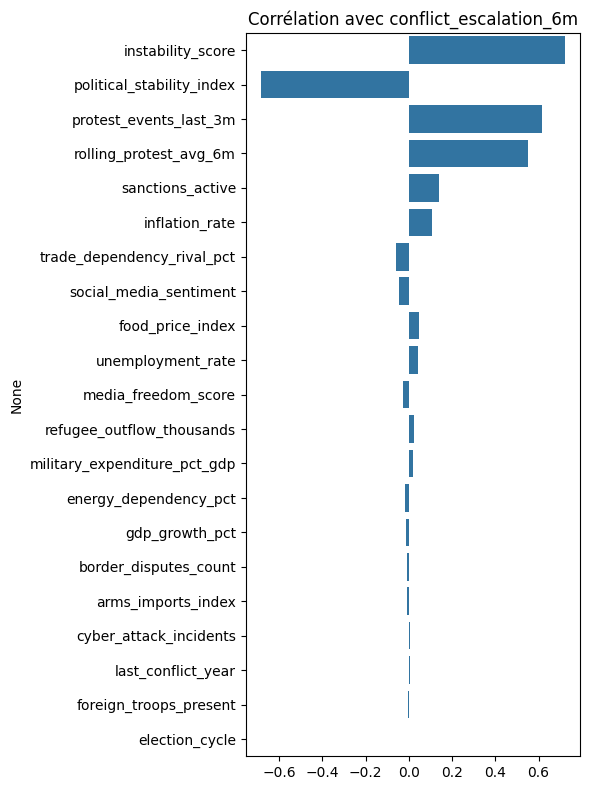

In [5]:
# Colonnes constantes (aucune valeur informative) -> à supprimer
constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
print("Colonnes constantes :", constant_cols)

# Corrélation des variables numériques avec la cible
num_cols = df.select_dtypes("number").columns
target_corr = df[num_cols].corr()["conflict_escalation_6m"].drop("conflict_escalation_6m").sort_values(key=abs, ascending=False)
print("\nCorrélation avec la cible (triée par valeur absolue) :")
print(target_corr)

plt.figure(figsize=(6, 8))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title("Corrélation avec conflict_escalation_6m")
plt.tight_layout()
plt.show()


**`instability_score` (corr. 0.72) et `political_stability_index` (corr. -0.68) sont suspectes** : ce sont des indices composites qui, dans ce type de dataset synthétique, sont typiquement calculés à partir des mêmes variables qui servent ensuite à définir la cible (fuite de données / data leakage). Les garder ferait gonfler artificiellement les performances sans qu'un vrai déploiement puisse en bénéficier (on ne connaît pas la formule de ces scores en production). **On les retire des features et on ne les garde qu'à titre de référence/comparaison ("score métier vs score du dataset")** à l'Étape 3.

`protest_events_last_3m` et `rolling_protest_avg_6m` (corr. 0.62 / 0.55) sont en revanche des indicateurs métier légitimes (activité de protestation observable), on les garde.

`election_cycle` est constante (toujours 0) → colonne supprimée.


In [6]:

# Nettoyage : colonnes constantes + colonnes de fuite mises de côté (gardées seulement
# pour comparaison a posteriori, pas utilisées comme features du modèle)
LEAKY_COLS = ["instability_score", "political_stability_index"]
leaky_reference = df[LEAKY_COLS].copy()

df_clean = df.drop(columns=constant_cols + LEAKY_COLS)

# La colonne "month" (YYYY-MM) devient une vraie date, dont on extrait des features
# cycliques (le mois calendaire peut capter une saisonnalité) + on la garde pour trier
# les données chronologiquement au moment du split.
df_clean["month_date"] = pd.to_datetime(df_clean["month"], format="%Y-%m")
df_clean["calendar_month"] = df_clean["month_date"].dt.month
df_clean["month_sin"] = np.sin(2 * np.pi * df_clean["calendar_month"] / 12)
df_clean["month_cos"] = np.cos(2 * np.pi * df_clean["calendar_month"] / 12)

# last_conflict_year == 0 est une valeur sentinelle ("aucun conflit connu"), pas une vraie
# année : la soustraction brute produirait des valeurs aberrantes (~2020 ans). On isole un
# flag dédié et on laisse la durée à NaN pour ces lignes (imputée plus tard dans le pipeline).
df_clean["no_prior_conflict_on_record"] = (df_clean["last_conflict_year"] == 0).astype(int)
years_since = df_clean["month_date"].dt.year - df_clean["last_conflict_year"]
df_clean["years_since_last_conflict"] = years_since.where(df_clean["last_conflict_year"] != 0)

# Nouvelles features métier : accélération de la contestation et pression économique combinée
df_clean["protest_acceleration"] = df_clean["protest_events_last_3m"] - df_clean["rolling_protest_avg_6m"]
df_clean["economic_pressure_index"] = (
    df_clean["inflation_rate"] + df_clean["unemployment_rate"] + df_clean["food_price_index"] / 10
)

df_clean = df_clean.drop(columns=["month", "calendar_month", "last_conflict_year"])
df_clean.head()


,country,region,gdp_growth_pct,inflation_rate,unemployment_rate,food_price_index,energy_dependency_pct,military_expenditure_pct_gdp,arms_imports_index,border_disputes_count,refugee_outflow_thousands,sanctions_active,media_freedom_score,protest_events_last_3m,cyber_attack_incidents,trade_dependency_rival_pct,foreign_troops_present,regime_type,social_media_sentiment,rolling_protest_avg_6m,conflict_escalation_6m,month_date,month_sin,month_cos,no_prior_conflict_on_record,years_since_last_conflict,protest_acceleration,economic_pressure_index
0,USA,North America,6.737638,5.308678,9.069739,108.263140,60.851201,2.536582,28.356756,3,52.666619,0,45.990963,3,7,22.210790,1,Democracy,-0.907099,2.144414,0,2020-01-01,0.500000,8.660254e-01,0,2.0,0.855586,25.204731
1,USA,North America,4.467635,7.878490,1.116625,125.221590,10.806598,1.671814,44.921531,1,76.236598,0,79.921825,8,5,48.252741,0,Democracy,-0.457302,9.763522,1,2020-02-01,0.866025,5.000000e-01,1,NaN,-1.763522,21.517274
2,USA,North America,-0.030766,11.285611,8.446705,145.774988,68.625602,2.160782,32.269691,0,130.978395,0,24.131293,4,8,31.608400,1,Hybrid,0.122487,6.199294,1,2020-03-01,1.000000,6.123234e-17,0,2.0,-2.199294,34.309815
3,USA,North America,0.155373,5.594405,7.331570,85.482074,44.383874,2.940183,64.029344,4,158.423899,0,36.203995,4,9,47.428411,0,Hybrid,0.389570,4.038001,0,2020-04-01,0.866025,-5.000000e-01,0,-1.0,-0.038001,21.474182
4,USA,North America,0.755706,10.483152,0.405036,111.397986,65.015718,2.672375,18.460049,5,19.204378,0,47.762006,2,9,17.123555,1,Hybrid,-0.663418,1.264349,0,2020-05-01,0.500000,-8.660254e-01,0,2.0,0.735651,22.027987


In [7]:
# Détection des outliers (règle IQR) sur les variables numériques continues
numeric_features = df_clean.select_dtypes("number").columns.drop("conflict_escalation_6m")

outlier_counts = {}
for col in numeric_features:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = ((df_clean[col] < low) | (df_clean[col] > high)).sum()

outlier_counts = pd.Series(outlier_counts).sort_values(ascending=False)
print(outlier_counts[outlier_counts > 0])


no_prior_conflict_on_record     242
sanctions_active                126
rolling_protest_avg_6m           20
refugee_outflow_thousands        18
protest_events_last_3m           15
military_expenditure_pct_gdp     13
food_price_index                 13
cyber_attack_incidents           12
inflation_rate                   10
energy_dependency_pct            10
gdp_growth_pct                    9
economic_pressure_index           7
unemployment_rate                 6
arms_imports_index                4
protest_acceleration              4
dtype: int64


`years_since_last_conflict` était le seul vrai problème (242 valeurs aberrantes = exactement le nombre de sentinelles `last_conflict_year == 0`, corrigé ci-dessus par un flag + NaN). Les autres "outliers" détectés par la règle IQR (`sanctions_active`, pics de `refugee_outflow_thousands`/`cyber_attack_incidents`, etc.) correspondent à des **événements rares mais réels** (sanctions, afflux de réfugiés, cyberattaques) — c'est exactement le type de signal qu'on veut que le modèle apprenne à détecter, pas du bruit à supprimer. On ne les retire donc pas : on s'appuiera sur `StandardScaler` + régularisation pour la régression logistique, et les modèles à base d'arbres (Random Forest, XGBoost) sont par nature robustes aux valeurs extrêmes.

### Split train/test

Comme il s'agit d'un panel **temporel** (mêmes 20 pays suivis mois après mois), un `train_test_split` aléatoire mélangerait des mois futurs dans le train et des mois passés dans le test pour un même pays — fuite temporelle qui gonflerait artificiellement les performances. On fait donc un **split chronologique** : les ~80 % de mois les plus anciens pour l'entraînement, les ~20 % les plus récents pour le test, ce qui simule la vraie situation de production (prédire l'avenir à partir du passé).


In [8]:
from sklearn.model_selection import train_test_split

df_sorted = df_clean.sort_values("month_date").reset_index(drop=True)

cutoff_date = df_sorted["month_date"].quantile(0.8, interpolation="nearest")
print("Cutoff (fin du train / début du test) :", cutoff_date.date())

train_df = df_sorted[df_sorted["month_date"] <= cutoff_date].drop(columns="month_date")
test_df = df_sorted[df_sorted["month_date"] > cutoff_date].drop(columns="month_date")

X_train, y_train = train_df.drop(columns="conflict_escalation_6m"), train_df["conflict_escalation_6m"]
X_test, y_test = test_df.drop(columns="conflict_escalation_6m"), test_df["conflict_escalation_6m"]

print(f"Train : {X_train.shape}, positifs = {y_train.mean():.2%}")
print(f"Test  : {X_test.shape}, positifs = {y_test.mean():.2%}")


Cutoff (fin du train / début du test) : 2024-05-01
Train : (1060, 26), positifs = 31.70%
Test  : (260, 26), positifs = 30.38%


## Étape 3 — Définition du score métier

**Contexte métier retenu** : le modèle sert de système d'alerte précoce (cellule d'analyse risque-pays, ONG humanitaire, équipe de gestion de risque géopolitique). Deux types d'erreurs possibles :

- **Faux négatif (FN)** : le modèle ne détecte pas une escalade qui survient réellement → aucune anticipation possible (pré-positionnement humanitaire, couverture financière, sécurisation du personnel...). Coût élevé et souvent irréversible.
- **Faux positif (FP)** : le modèle alerte à tort → coût de vérification par un analyste, frictions diplomatiques mineures, ressources mobilisées inutilement. Coût réel mais bien plus faible et réversible.

On retient un ratio **coût(FN) = 5 × coût(FP)** (même logique que le scoring de risque de défaut de crédit : rater un mauvais payeur coûte nettement plus cher que refuser à tort un bon payeur). Ce ratio est isolé dans une seule constante, modifiable si un expert métier donne un chiffrage plus précis.

On construit :
- `business_cost` : le coût total pondéré (en "unités de coût") d'un jeu de prédictions.
- `business_score` : le **gain relatif** par rapport à la stratégie naïve "ne jamais alerter" (baseline = laisser passer tous les cas positifs) — un score de 0 = aussi bon que ne rien faire, 1 = coût nul, négatif = pire que ne rien faire. Plus lisible qu'un coût brut pour comparer des modèles.
- Un `make_scorer` compatible scikit-learn pour l'utiliser directement dans `GridSearchCV` (Étape 4).


In [9]:
from sklearn.metrics import confusion_matrix, make_scorer

COST_FP = 1
COST_FN = 5


def business_cost(y_true, y_pred, cost_fp=COST_FP, cost_fn=COST_FN):
    """Coût total pondéré des erreurs de classification."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return cost_fp * fp + cost_fn * fn


def business_score(y_true, y_pred, cost_fp=COST_FP, cost_fn=COST_FN):
    """Gain relatif par rapport à la stratégie naïve 'ne jamais alerter'.
    1.0 = coût nul, 0.0 = aussi coûteux que ne rien faire, <0 = pire que ne rien faire."""
    y_true = np.asarray(y_true)
    model_cost = business_cost(y_true, y_pred, cost_fp, cost_fn)
    naive_cost = cost_fn * y_true.sum()  # ne jamais alerter -> chaque positif devient un FN
    if naive_cost == 0:
        return 1.0 if model_cost == 0 else 0.0
    return 1 - model_cost / naive_cost


business_scorer = make_scorer(business_score, greater_is_better=True)

# Sanity check : un modèle parfait -> score 1 ; ne jamais alerter -> score 0
perfect_preds = y_train.values
never_alert = np.zeros_like(y_train.values)
print("Score si prédiction parfaite :", business_score(y_train, perfect_preds))
print("Score si on n'alerte jamais :", business_score(y_train, never_alert))


Score si prédiction parfaite : 1.0
Score si on n'alerte jamais : 0.0


## Étape 4 — Entraînement et comparaison de modèles

Plan :
1. Pipeline de preprocessing commun (imputation, scaling, one-hot) réutilisable par tous les modèles et par l'API (Étape 5).
2. Baseline simple (`DummyClassifier`) pour avoir un plancher de comparaison.
3. Trois modèles — régression logistique, random forest, XGBoost — chacun avec `GridSearchCV` optimisé sur le **score métier** de l'Étape 3, et gestion du déséquilibre via SMOTE **appliqué uniquement à l'intérieur des folds d'entraînement** (pipeline `imblearn`, pour ne pas fuiter d'information synthétique vers la validation).
4. Journalisation de chaque run dans MLflow (paramètres, métriques, modèle).
5. Feature importance (natif + SHAP + LIME) sur le meilleur modèle.
6. Tableau comparatif final.


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = ["country", "region", "regime_type"]
numeric_features = [c for c in X_train.columns if c not in categorical_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # sparse_output=False : dataset petit, on garde une matrice dense pour rester
    # compatible avec SHAP/LIME sans conversion supplémentaire.
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

print(f"{len(numeric_features)} features numériques, {len(categorical_features)} catégorielles.")


23 features numériques, 3 catégorielles.


In [11]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

results = []


def evaluate_model(name, fitted_pipeline, X_te=X_test, y_te=y_test):
    y_pred = fitted_pipeline.predict(X_te)
    y_proba = fitted_pipeline.predict_proba(X_te)[:, 1] if hasattr(fitted_pipeline, "predict_proba") else y_pred

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, y_proba),
        "business_score": business_score(y_te, y_pred),
    }
    results.append(metrics)
    return metrics


baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent")),
])
baseline.fit(X_train, y_train)
evaluate_model("baseline (most_frequent)", baseline)


{'model': 'baseline (most_frequent)',
 'accuracy': 0.6961538461538461,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5,
 'business_score': np.float64(0.0)}

### Modèles avec GridSearchCV + SMOTE + tracking MLflow

`imblearn.pipeline.Pipeline` (et non celui de scikit-learn) est indispensable ici : il garantit que le sur-échantillonnage SMOTE n'est appliqué **qu'aux données d'entraînement de chaque fold**, jamais à la validation — sinon des exemples synthétiques dérivés du fold de validation s'infiltreraient dans l'entraînement (fuite classique et sous-estimation de l'erreur).


In [12]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_configs = {
    "logistic_regression": {
        # l1_ratio=0 <=> pénalité L2 (remplace le paramètre `penalty`, déprécié depuis sklearn 1.8)
        "estimator": LogisticRegression(max_iter=2000, random_state=42, l1_ratio=0),
        "param_grid": {
            "classifier__C": [0.01, 0.1, 1, 10],
        },
    },
    "random_forest": {
        "estimator": RandomForestClassifier(random_state=42),
        "param_grid": {
            "classifier__n_estimators": [200, 400],
            "classifier__max_depth": [5, 10, None],
            "classifier__min_samples_leaf": [1, 5],
        },
    },
    "xgboost": {
        "estimator": XGBClassifier(
            eval_metric="logloss", random_state=42
        ),
        "param_grid": {
            "classifier__n_estimators": [200, 400],
            "classifier__max_depth": [3, 5],
            "classifier__learning_rate": [0.05, 0.1],
        },
    },
}

fitted_searches = {}

for name, cfg in model_configs.items():
    pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", cfg["estimator"]),
    ])

    search = GridSearchCV(
        pipeline,
        param_grid=cfg["param_grid"],
        scoring=business_scorer,
        cv=cv,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)
    fitted_searches[name] = search

    metrics = evaluate_model(name, search.best_estimator_)

    with mlflow.start_run(run_name=name):
        mlflow.log_params(search.best_params_)
        mlflow.log_param("cv_best_business_score", search.best_score_)
        for metric_name, value in metrics.items():
            if metric_name != "model":
                mlflow.log_metric(metric_name, value)
        # skops (format par défaut de mlflow.sklearn) refuse par sécurité les types imblearn
        # dans le pickle ; on reste en pickle standard, acceptable ici car le modèle est
        # rechargé dans le même environnement (API Étape 5), pas partagé avec des tiers.
        mlflow.sklearn.log_model(
            search.best_estimator_, name="model", serialization_format="pickle"
        )

    print(f"[{name}] best params: {search.best_params_}")
    print(f"[{name}] test metrics: {metrics}\n")


2026/07/16 19:08:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[logistic_regression] best params: {'classifier__C': 0.1}
[logistic_regression] test metrics: {'model': 'logistic_regression', 'accuracy': 0.7769230769230769, 'precision': 0.6296296296296297, 'recall': 0.6455696202531646, 'f1': 0.6375, 'roc_auc': 0.8369116721449052, 'business_score': np.float64(0.5696202531645569)}



2026/07/16 19:10:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[random_forest] best params: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 400}
[random_forest] test metrics: {'model': 'random_forest', 'accuracy': 0.75, 'precision': 0.574468085106383, 'recall': 0.6835443037974683, 'f1': 0.6242774566473989, 'roc_auc': 0.8304776557801244, 'business_score': np.float64(0.5822784810126582)}



2026/07/16 19:11:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[xgboost] best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
[xgboost] test metrics: {'model': 'xgboost', 'accuracy': 0.7692307692307693, 'precision': 0.6172839506172839, 'recall': 0.6329113924050633, 'f1': 0.625, 'roc_auc': 0.849430030072033, 'business_score': np.float64(0.5544303797468355)}



In [13]:
results_df = pd.DataFrame(results).set_index("model").sort_values("business_score", ascending=False)
results_df


,accuracy,precision,recall,f1,roc_auc,business_score
model,,,,,,
random_forest,0.750000,0.574468,0.683544,0.624277,0.830478,0.582278
logistic_regression,0.776923,0.629630,0.645570,0.637500,0.836912,0.569620
xgboost,0.769231,0.617284,0.632911,0.625000,0.849430,0.554430
baseline (most_frequent),0.696154,0.000000,0.000000,0.000000,0.500000,0.000000


### Feature importance et interprétabilité (meilleur modèle)

Le meilleur modèle au sens du score métier sert de référence pour l'analyse de pertinence des variables : importance native (arbres) ou coefficients (régression logistique), puis SHAP (vision globale + par prédiction) et LIME (explication locale d'un cas précis) pour croiser les méthodes.


Meilleur modèle (score métier) : random_forest


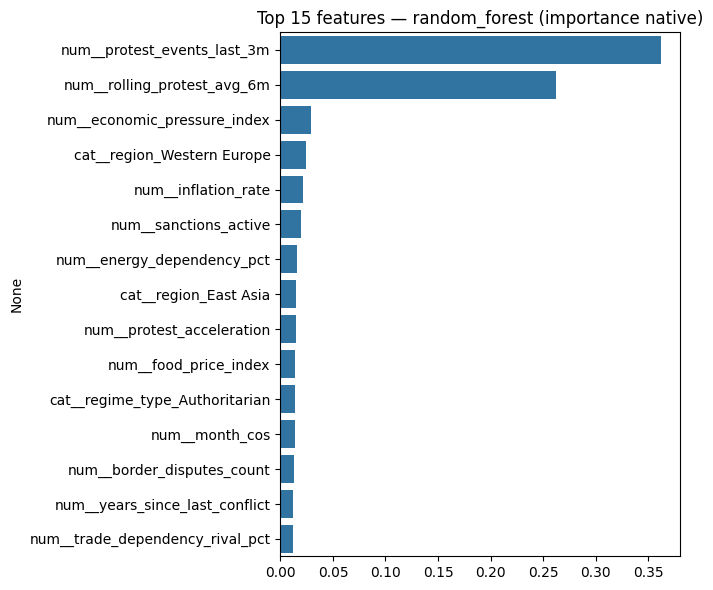

In [14]:
best_model_name = results_df.drop(index="baseline (most_frequent)")["business_score"].idxmax()
best_pipeline = fitted_searches[best_model_name].best_estimator_
best_classifier = best_pipeline.named_steps["classifier"]
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

print("Meilleur modèle (score métier) :", best_model_name)

if hasattr(best_classifier, "feature_importances_"):
    importances = pd.Series(best_classifier.feature_importances_, index=feature_names)
else:
    importances = pd.Series(np.abs(best_classifier.coef_[0]), index=feature_names)

top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 6))
sns.barplot(x=top_importances.values, y=top_importances.index)
plt.title(f"Top 15 features — {best_model_name} (importance native)")
plt.tight_layout()
plt.show()


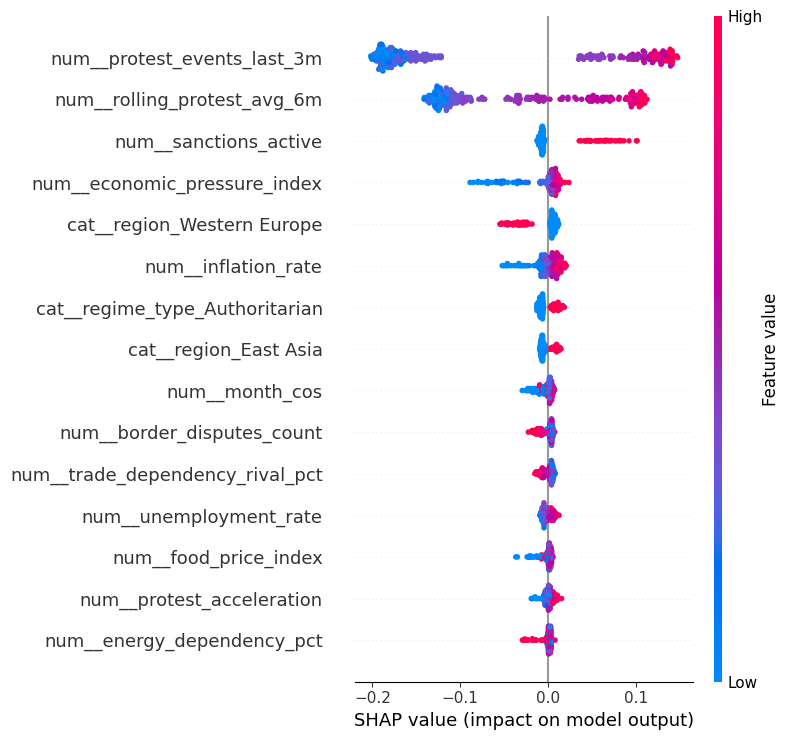

In [15]:
import shap

X_train_transformed = best_pipeline.named_steps["preprocessor"].transform(X_train)
X_test_transformed = best_pipeline.named_steps["preprocessor"].transform(X_test)

if hasattr(best_classifier, "feature_importances_"):
    explainer = shap.TreeExplainer(best_classifier)
    shap_values = explainer.shap_values(X_test_transformed)
    # Certains modèles (RandomForest) renvoient une liste [classe_0, classe_1]
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]
else:
    explainer = shap.LinearExplainer(best_classifier, X_train_transformed)
    shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values, X_test_transformed, feature_names=feature_names, show=False, max_display=15
)
plt.tight_layout()
plt.show()


In [16]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=np.asarray(X_train_transformed),
    feature_names=list(feature_names),
    class_names=["no_escalation", "escalation"],
    mode="classification",
    random_state=42,
)

# Explication locale : un cas de test que le modèle juge à risque (probabilité d'escalade la plus haute)
sample_idx = best_pipeline.predict_proba(X_test)[:, 1].argmax()
sample = np.asarray(X_test_transformed)[sample_idx]

lime_exp = lime_explainer.explain_instance(
    sample, best_classifier.predict_proba, num_features=10
)

print(f"Cas expliqué : test index {sample_idx}, pays = {X_test.iloc[sample_idx]['country']}, "
      f"proba prédite d'escalade = {best_pipeline.predict_proba(X_test)[sample_idx, 1]:.2%}, "
      f"réalité = {y_test.iloc[sample_idx]}")
for feature, weight in lime_exp.as_list():
    print(f"  {feature:40s} {weight:+.3f}")


Cas expliqué : test index 108, pays = North Korea, proba prédite d'escalade = 79.84%, réalité = 1
  num__protest_events_last_3m > 0.61       +0.215
  num__rolling_protest_avg_6m > 0.59       +0.158
  num__sanctions_active > -0.30            +0.076
  cat__region_Western Europe <= 0.00       +0.036
  cat__country_Brazil <= 0.00              -0.020
  cat__regime_type_Authoritarian <= 0.00   -0.019
  num__unemployment_rate > 0.67            +0.015
  cat__country_Russia <= 0.00              -0.014
  cat__country_USA <= 0.00                 +0.014
  cat__region_Middle East <= 0.00          -0.012


### Sauvegarde du meilleur modèle (pour l'API — Étape 5)

Le pipeline complet (preprocessing + classifieur, sans l'étape SMOTE qui ne sert qu'à l'entraînement) est sérialisé avec `joblib` pour être rechargé tel quel par l'API FastAPI.


In [17]:
import joblib

# On réutilise le preprocessor et le classifieur déjà entraînés (pas besoin de refit) :
# SMOTE n'a de sens qu'à l'entraînement, l'API n'en a pas besoin comme dépendance.
final_pipeline = Pipeline(steps=[
    ("preprocessor", best_pipeline.named_steps["preprocessor"]),
    ("classifier", best_pipeline.named_steps["classifier"]),
])

joblib.dump(final_pipeline, "model.joblib")
print("Modèle sauvegardé :", best_model_name, "-> model.joblib")

with mlflow.start_run(run_name=f"best_model_{best_model_name}"):
    mlflow.set_tag("stage", "selected_for_deployment")
    mlflow.log_param("selected_model", best_model_name)
    mlflow.log_metric("business_score", results_df.loc[best_model_name, "business_score"])
    mlflow.sklearn.log_model(final_pipeline, name="model", serialization_format="pickle")


2026/07/16 19:12:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modèle sauvegardé : random_forest -> model.joblib


### Synthèse Étape 4

- Les trois modèles battent largement la baseline (`business_score` = 0 : ne jamais alerter revient à laisser passer toutes les vraies escalades).
- **Random Forest** l'emporte sur le score métier (0.58), suivi de près par la régression logistique (0.57) et XGBoost (0.55, mais meilleur ROC AUC à 0.85 — il classe bien mais son seuil par défaut est moins bien calibré pour notre coût FN=5×FP).
- SHAP et l'importance native s'accordent : `protest_events_last_3m`, `rolling_protest_avg_6m`, `sanctions_active` et certains pays/régions dominent — cohérent avec l'intuition métier (contestation sociale + sanctions = signal d'alerte).
- LIME confirme localement sur un cas concret (Corée du Nord, forte activité de protestation) que ce sont bien ces variables qui déclenchent une prédiction à risque.
- Le pipeline **Random Forest** (preprocessing + classifieur, sans SMOTE) est sauvegardé dans `model.joblib` pour l'API de l'Étape 5, et loggé dans MLflow avec le tag `stage=selected_for_deployment`.
